## Generating dataset (x_mu, y_mu), mu = 1,...,n


In [1]:
import math
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt


In [2]:
def gen_data(
    d: int, # hidden manifold dimension
    alpha: float, # n/p
    gamma: float, # d/p
    F: NDArray[np.floating], # size: dxp,
    theta_0: NDArray[np.floating], # size: dx1,
    sigma,
    f_0,
) -> tuple[NDArray[np.floating], NDArray[np.floating]]:

    p = math.floor(d / gamma) # number of features
    n = math.floor(alpha * p) # number of samples

    # drawing C (nxd) with i.i.d. N(0, 1) entries
    C = np.random.normal(0, 1, size=(n, d))

    y = f_0(C @ theta_0)
    X = sigma(C @ F)

    return X, y

In [3]:
d=100
alpha = 0.5
gamma = 0.1
F = np.random.normal(0, 1, size=(d,  math.floor(d / gamma))) # Gaussian projections
theta_0=np.random.normal(0, 1, size=(d,))

X, y = gen_data(d=d, alpha=alpha, gamma=gamma, 
         F=F, theta_0=theta_0, sigma=lambda x: np.sign(x), f_0=lambda x: np.sign(x))


In [4]:
X

array([[-1.,  1., -1., ..., -1.,  1., -1.],
       [-1.,  1.,  1., ..., -1.,  1.,  1.],
       [-1.,  1.,  1., ...,  1.,  1.,  1.],
       ...,
       [ 1.,  1.,  1., ...,  1.,  1.,  1.],
       [ 1., -1.,  1., ..., -1., -1., -1.],
       [ 1.,  1.,  1., ..., -1., -1.,  1.]], shape=(500, 1000))

In [5]:
y

array([-1., -1., -1., -1., -1., -1., -1.,  1., -1.,  1.,  1., -1., -1.,
        1., -1., -1., -1.,  1., -1.,  1.,  1., -1., -1., -1.,  1., -1.,
       -1., -1., -1., -1.,  1.,  1.,  1.,  1., -1., -1.,  1.,  1., -1.,
        1., -1.,  1., -1., -1.,  1.,  1.,  1., -1.,  1., -1., -1., -1.,
        1., -1., -1., -1.,  1., -1.,  1.,  1., -1.,  1.,  1.,  1.,  1.,
       -1.,  1., -1.,  1., -1., -1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,
       -1.,  1.,  1., -1.,  1.,  1., -1., -1.,  1.,  1., -1.,  1.,  1.,
       -1., -1., -1.,  1.,  1., -1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1., -1., -1., -1., -1., -1.,  1.,  1.,  1., -1.,  1.,  1.,
        1.,  1., -1., -1.,  1.,  1.,  1., -1.,  1.,  1.,  1., -1., -1.,
       -1., -1., -1., -1.,  1., -1., -1.,  1., -1., -1.,  1., -1., -1.,
       -1., -1.,  1.,  1.,  1., -1., -1., -1., -1., -1.,  1., -1.,  1.,
        1.,  1.,  1., -1., -1.,  1.,  1., -1.,  1.,  1., -1., -1., -1.,
       -1., -1.,  1.,  1., -1., -1.,  1.,  1.,  1., -1.,  1.,  1

In [38]:
def ave_gen_error(
    d: int, # hidden manifold dimension
    alpha: float, # n/p
    gamma: float, # d/p
    lamb: float,
    sigma,
    f_0,
    f_hat,
    n_seeds: int,
    k=1
) -> tuple[float, float]:

    p = math.floor(d / gamma) # number of features
    n = math.floor(alpha * p) # number of samples

    E_g = 0

    for i in range(1, n_seeds+1):
        # draw F, theta_0

        F = np.random.normal(0, 1, size=(d,  math.floor(d / gamma))) # Gaussian projections
        theta_0=np.random.normal(0, 1, size=(d,))

        X, y = gen_data(d=d, alpha=alpha, gamma=gamma, 
         F=F, theta_0=theta_0, sigma=lambda x: np.sign(x), f_0=lambda x: np.sign(x))
 
        ## Square Loss
        if n>p:
            w_hat = np.linalg.inv((X.T @ X + lamb * np.eye(p))) @ X.T @ y
        else:
            w_hat = X.T @ np.linalg.inv((X@ X.T + lamb * np.eye(n))) @ y
        
        loss = 1/2 * np.linalg.norm(y -  f_hat(X @ w_hat)) + lamb/2 * np.linalg.norm(w_hat)**2
        print(f"Training Loss: {loss}")
        
        X_new, y_new = gen_data(d=d, alpha=alpha, gamma=gamma, 
         F=F, theta_0=theta_0, sigma=lambda x: np.sign(x), f_0=lambda x: np.sign(x))
        #???

        
        E_g = E_g + (1/(4**k*n)) * np.linalg.norm(y_new -  f_hat(X_new @ w_hat))**2

    return E_g/n_seeds, loss

In [39]:
gen_errors = []
alphas = []
losses = []


for i in range(1,100):
    alpha = 1/i*20
    alphas.append(alpha)

    d=100
    gamma = alpha/3
    print(i)
    eps_g, loss = ave_gen_error(d=d, alpha=alpha, gamma=gamma, 
                      lamb=1e-4, sigma=lambda x: np.sign(x), 
                      f_0=lambda x: np.sign(x), f_hat=lambda x: np.sign(x), 
                      n_seeds=10)
    gen_errors.append(eps_g)
    losses.append(loss)

1
Training Loss: 10.000011376056387
Training Loss: 10.583009559760404
Training Loss: 10.440310967709383
Training Loss: 10.48809220888074
Training Loss: 10.535659745749378
Training Loss: 10.392311475219502
Training Loss: 10.344088113675491
Training Loss: 9.848865428329244
Training Loss: 9.380842277649405
Training Loss: 10.246956348875937
2
Training Loss: 9.433988013346145
Training Loss: 9.949882266948347
Training Loss: 9.746805450438151
Training Loss: 10.723810696858028
Training Loss: 9.797966421811104
Training Loss: 9.327391589673546
Training Loss: 9.89950651031751
Training Loss: 9.949884964453629
Training Loss: 9.000015957046418
Training Loss: 9.643664755244444
3
Training Loss: 9.797973715733699
Training Loss: 8.831781547759071
Training Loss: 8.185375207489043
Training Loss: 8.602343664411505
Training Loss: 9.59167779434219
Training Loss: 8.544024001598325
Training Loss: 8.48530701791331
Training Loss: 8.124057282006193
Training Loss: 9.591677873481265
Training Loss: 9.48684487764973


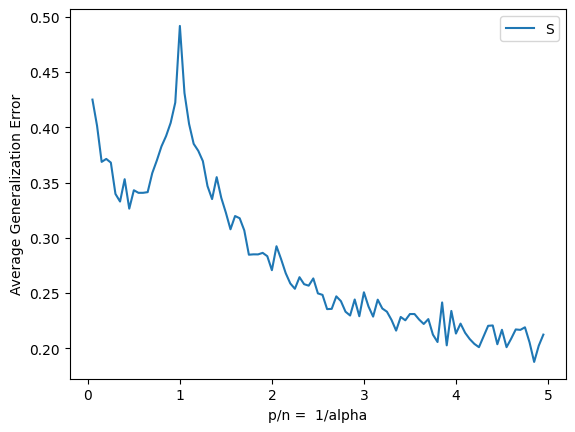

In [40]:
plt.plot([1/alpha for alpha in alphas],gen_errors)
plt.xlabel('p/n =  1/alpha')
plt.ylabel('Average Generalization Error')
plt.legend("Square Loss")

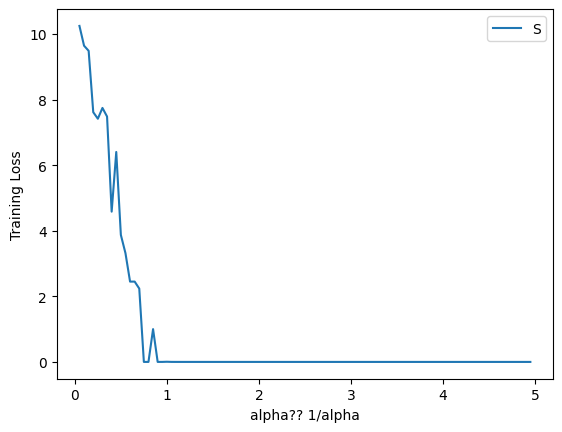

In [41]:
plt.plot([1/alpha for alpha in alphas], losses)
plt.xlabel('alpha?? 1/alpha')
plt.ylabel('Training Loss')
plt.legend("Square Loss")